# CNN Image Classifier (Chinese Traffic Signs)

Convolutional neural network (CNN) image classifier project using a Kaggle dataset containing images of Chinese traffic signs. This project demonstrates CNN-specific data preprocessing, basic CNN building and testing, data augmentation exploration within CNNs, transfer learning for image prediction, analysis of CNN image prediction results, and implementing the CNN model within a user-friendly script that can display interpretable, human-readable traffic sign predictions from user-provided traffic sign images.

## Objectives

- Preprocess data properly for CNN input
- Build, train, and test multiple CNNs
- Explore the effect of data augmentation on results specifically for the dataset used in this project
- Determine performance of Google's widely-used MobileNetV2 CNN model with this dataset; compare with and without trainable parameters in the base model
- Save CNNs to disk
- Implement saved CNNs in user-friendly scripts that can provide clear, comprehensible, and interpretable image predictions.

## Tools and libraries

- Python
- Kagglehub
- pandas
- ipywidgets
- scikit-learn
- PIL
- matplotlib
- NumPy
- TensorFlow
- seaborn

### 1. Import data and create training, validation, and testing splits

All data is imported from Kaggle.

#### Downloading the dataset

The `kagglehub` API is used to directly download the dataset used for this project to disk. A directory is created that contains a `.csv` file with selected features and labels for each downloaded image, and an `images/` directory containing all 6164 Chinese traffic sign images used for this project.

In [1]:
from pathlib import Path
import kagglehub
import os

# Local path to dataset directory
PATH = Path('.cache/kagglehub/datasets/dmitryyemelyanov/chinese-traffic-signs/versions/2/')

if PATH.is_dir():
    print('Dataset already downloaded from Kaggle.')
else:
    PATH = kagglehub.dataset_download('dmitryyemelyanov/chinese-traffic-signs')

os.listdir(PATH)

['images', 'annotations.csv']

#### Exploring the dataset

The downloaded `annotations.csv` file is converted to a pandas DataFrame and printed below, with all features and labels for each image.

In [2]:
import pandas as pd

data = pd.read_csv(f'{PATH}/annotations.csv')
data

,file_name,width,height,x1,y1,x2,y2,category
0,000_0001.png,134,128,19,7,120,117,0
1,000_0002.png,165,151,23,12,149,138,0
2,000_0003.png,128,122,22,14,116,105,0
3,000_0010.png,80,73,14,8,67,63,0
4,000_0011.png,186,174,36,15,155,157,0
...,...,...,...,...,...,...,...,...
6159,056_1_0018_1_j.png,122,94,25,20,80,79,56
6160,056_1_0019_1_j.png,224,207,39,39,188,178,56
6161,056_1_0020_1_j.png,128,115,32,30,89,79,56
6162,057_1_0001_1_j.png,100,95,21,22,74,75,57


In total, there are 6164 Chinese traffic sign images with six different features and a label for each.

#### Create training, validation, and testing splits for the data

Scikit-learn's `train_test_split` function is called twice to create training, validation, and testing splits for this data. A ~70/15/15 split was used for this project. Stratification is used across splits to preserve class distributions; some traffic sign types appear more frequently than others, and a few of the rarest classes have only a handful of images in total, so their precision, recall, and F1 scores in later evaluation sections should be interpreted with that small sample size in mind.

The shape of each split is then printed to make sure each split has proper dimensionality.

In [3]:
from sklearn.model_selection import train_test_split

X = data.iloc[:, :-1]       # features
y = data.iloc[:, -1]        # labels

# Split into training, validation, and testing
# First, create testing split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, 
                                                  random_state=42, stratify=y, 
                                                  shuffle=True)

# Then, create training and validation splits

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, # 0.18 * 0.85 ~ 0.15
                                                  random_state=42, stratify=y_temp, 
                                                  shuffle=True)

print('Shape of X splits:')
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'X_test shape: {X_test.shape}')

print('\n')

print('Shape of y splits:')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')
print(f'y_test shape: {y_test.shape}')

Shape of X splits:
X_train shape: (4295, 7)
X_val shape: (944, 7)
X_test shape: (925, 7)


Shape of y splits:
y_train shape: (4295,)
y_val shape: (944,)
y_test shape: (925,)


#### Inspect one image from dataset

To better understand the dataset we will be using for this project, an example image is printed below. 

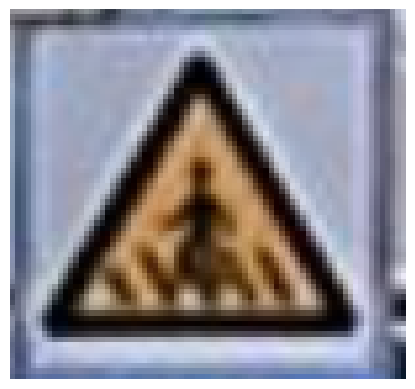

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

# View one image

ex_img_path = os.path.join(f'{PATH}/images/035_0007_j.png')

img = Image.open(ex_img_path)

plt.figure()
plt.imshow(img)
plt.axis('off')
plt.show()

The different colors and size of the image are what the CNNs will use to classify images.

### 2. Preprocess the data

All images must be preprocessed for CNN input. 

Image objects must have identical shapes when used to train a CNN; this means all image features must be identical. The typical shape of an image object for CNN training is (`image_width`, `image_height`, `number_of_color_channels`). 

- Three color channels are created using `RGB`
- Images are resized to 32x32; a common size to use in CNN training
- Image object color ranges are normalized so that they range from 0 to 1 instead of the typical range of 0 to 255 (256 different possible levels of color)

#### Create and test the preprocessing workflow

The shape, as well as maximum and minimum RGB values of one processed image example are also printed to confirm that the preprocessing workflow is executed correctly before preprocessing the entire dataset.

In [5]:
import numpy as np

img_size = 32   # Typical image width and height for CNN training

def process_img(path):
    rgb_img = Image.open(path).convert('RGB')
    resize_img = np.array(rgb_img.resize((img_size, img_size)))
    final_img = resize_img / 255.0
    return final_img

ex_proc_img = process_img(ex_img_path)

print(f'Example processed image shape: {ex_proc_img.shape}')
print(f'Max normalized RGB value: {ex_proc_img.max()}')
print(f'Min normalized RGB value: {ex_proc_img.min()}')

Example processed image shape: (32, 32, 3)
Max normalized RGB value: 0.9882352941176471
Min normalized RGB value: 0.0


Shape is (32, 32, 3) as expected; RGB values range from 0 to 1; preprocessing is done correctly.

#### Preprocessing the entire dataset

Preprocess all splits created and print shapes to determine proper execution.

In [6]:
def process_img_batch(X_split, y_split):

    processed_split_X = []
    processed_split_y = []

    for (_, row), y in zip(X_split.iterrows(), y_split):
        filename = row['file_name']
        path = os.path.join(f'{PATH}/images/{filename}')
        processed_img = process_img(path)
        processed_split_X.append(processed_img)
        processed_split_y.append(y)

    return np.array(processed_split_X), np.array(processed_split_y)

X_train_proc, y_train = process_img_batch(X_train, y_train)
X_val_proc, y_val = process_img_batch(X_val, y_val)
X_test_proc, y_test = process_img_batch(X_test, y_test)

print('Shape of X splits:')
print(f'X_train shape: {X_train_proc.shape}')
print(f'X_val shape: {X_val_proc.shape}')
print(f'X_test shape: {X_test_proc.shape}')

print('\n')

print('Shape of y splits:')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')
print(f'y_test shape: {y_test.shape}')

print('\n')

# Example image metrics

ex_proc_img_2 = X_train_proc[50]

print(f'Example processed image shape: {ex_proc_img_2.shape}')
print(f'Max normalized RGB value: {ex_proc_img_2.max()}')
print(f'Min normalized RGB value: {ex_proc_img_2.min()}')

Shape of X splits:
X_train shape: (4295, 32, 32, 3)
X_val shape: (944, 32, 32, 3)
X_test shape: (925, 32, 32, 3)


Shape of y splits:
y_train shape: (4295,)
y_val shape: (944,)
y_test shape: (925,)


Example processed image shape: (32, 32, 3)
Max normalized RGB value: 0.7843137254901961
Min normalized RGB value: 0.00784313725490196


All shapes and color ranges are correct; first dimension in X and y splits are batch sizes.

#### Reshape y splits

In order to be used as input for CNNs, y splits must have shape `(batch_size, number_of_labels)`. Using TensorFlow's `to_categorical` function, y splits can be reshaped properly.

In [7]:
from tensorflow.keras.utils import to_categorical

num_cat = y.nunique()   # Total number of labels

y_train_proc = to_categorical(y_train, num_cat)
y_val_proc = to_categorical(y_val, num_cat)
y_test_proc = to_categorical(y_test, num_cat)

print('Shape of y splits:')
print(f'y_train_proc shape: {y_train_proc.shape}')
print(f'y_val_proc shape: {y_val_proc.shape}')
print(f'y_test_proc shape: {y_test_proc.shape}')

Shape of y splits:
y_train_proc shape: (4295, 58)
y_val_proc shape: (944, 58)
y_test_proc shape: (925, 58)


y splits now have the proper shapes, which means we can move on to CNN building and training.

### 3. Building, training, and evaluating a basic CNN

CNNs are used specifically for this image classification project because of their heightened ability to learn spatial patterns compared to other types of machine learning models. 

#### Building the model

A basic CNN is created using TensorFlow:

- Convolutional layers extract parameters from images by passing filters over them,
- Pooling layers reduce dimensionality and lower likelihood of learning noise-like patterns, which helps to prevent overfitting on training data,
- Flattening is used to reshape the final hidden layer to one dimension, which is essential for the final categorization step where a dense layer is used,
- A dense layer uses all information from the final flattened hidden layer to categorize images

The number of filters used in each convolutional layer increases sequentially, allowing the model to learn more complex patterns in deeper layers.

A softmax activation function is used in the final dense layer to provide probabilities of sign type for each image by the model, increasing interpretability.

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras import layers

model = Sequential([layers.Input(shape=(32, 32, 3)),
                    Conv2D(32, (3, 3), activation='relu'),
                    MaxPooling2D((2, 2)),

                    Conv2D(64, (3, 3), activation='relu'),
                    MaxPooling2D((2, 2)),

                    Conv2D(128, (3, 3), activation='relu'),
                    MaxPooling2D((2, 2)),

                    Flatten(),

                    Dense(num_cat, activation='softmax')

                    ])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 58)             │        29,754 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,002 (480.48 KB)

 Trainable params: 123,002 (480.48 KB)

 Non-trainable params: 0 (0.00 B)

The `Param #` column in the table above displays the number of parameters created at each step in the model architecture. Convolutional layers create parameters by passing filters over the images, while pooling layers are only used to reduce dimensionality and do not create parameters. 

The number of parameters created from a convolutional layer depends on the number of filters, the filter size, and the depth of the input data for that layer, plus a bias for each filter. 

The `Output Shape` column shows the shape of the data after passing through a given layer.

#### Compiling and training the model

Following model building, the model is compiled with an optimizer, loss function, and chosen metrics to record. The model is then fit to the training splits, and performance is evaluated using the validation splits. 

A large number of epochs (50) are used to train all models in this project because `callbacks.EarlyStopping` stops model training when validation metrics are no longer improving, meaning the model won't train on all 50 epochs unless validation metrics are still improving up to that point. 

The best model weights are also restored for the final saved model.

The optimizer, loss function, and batch size chosen are all standard for basic CNN usage, and were not tampered with over the course of this project.

In [34]:
from tensorflow.keras import callbacks

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_orig = model.fit(
    X_train_proc,
    y_train_proc,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_proc, y_val_proc),
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", restore_best_weights=True)]
)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1991 - loss: 3.2574 - val_accuracy: 0.3453 - val_loss: 2.5070
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4531 - loss: 2.0183 - val_accuracy: 0.5710 - val_loss: 1.6279
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6603 - loss: 1.2369 - val_accuracy: 0.7108 - val_loss: 0.9941
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7809 - loss: 0.7949 - val_accuracy: 0.8326 - val_loss: 0.6389
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8650 - loss: 0.5140 - val_accuracy: 0.8665 - val_loss: 0.4827
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8950 - loss: 0.3728 - val_accuracy: 0.8983 - val_loss: 0.3606
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9274 - loss: 0.2721 - val_accuracy: 0.9025 - val_loss: 0.2991
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9476 - loss: 0.2077 - val_accuracy: 0.9142 - v

Accuracy is quite low after training on the first few epochs as the model adjusts weights, but improves substantially over the next few epochs. Training on the final couple of epochs gives high, consistent accuracy metrics for both the training and validation sets, indicating effective model training for a highly-accurate classifier with minimal overfitting.

The loss function substantially decreases in value over epochs as well, indicating the optimization process working effectively.

#### Detailed model evaluation on the validation set

A classification report and confusion matrix are created to display results for final model fitting on the validation data.

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
                                                            precision    recall  f1-score   support

                                      Speed limit (5 km/h)      1.000     0.950     0.974        20
                                     Speed limit (15 km/h)      0.667     0.750     0.706         8
                                     Speed limit (30 km/h)      0.833     0.952     0.889        21
                                     Speed limit (40 km/h)      0.943     0.943     0.943        53
                                     Speed limit (50 km/h)      0.960     1.000     0.980        24
                                     Speed limit (60 km/h)      1.000     0.892     0.943        37
                                     Speed limit (70 km/h)      0.789     0.882     0.833        17
                                     Speed limit (80 km/h)      0.967     0.935     0.951        31
                 No driving straight ahead or turning left  

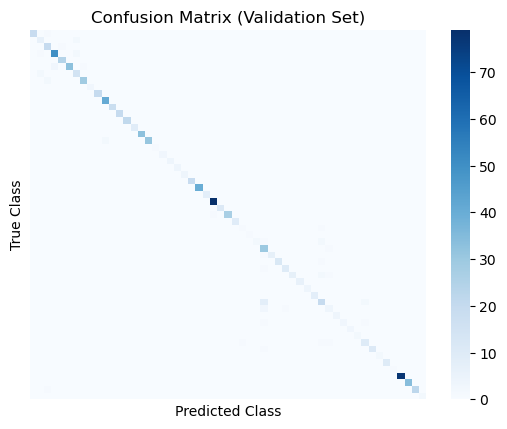

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from labels import LABELS

# Print all results from model predictions

def evaluate_model_performance(trained_model, X_split, y_split, labels, split_name):

    # Predictions

    y_pred = trained_model.predict(X_split)
    y_pred_choice = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_split, axis=1)

    # Classification report

    # Account for some labels not being present in validation and test sets

    present_numeric_labels = []

    for numeric_label in list(y_true) + list(y_pred_choice):
        if numeric_label not in present_numeric_labels:
            present_numeric_labels.append(numeric_label)

    present_numeric_labels = sorted(present_numeric_labels)

    final_labels = []

    for val in present_numeric_labels:
        read_label = labels[val]
        final_labels.append(read_label)

    print(classification_report(y_true, y_pred_choice, target_names=final_labels, digits=3, 
                                zero_division=0))

    # Confusion matrix

    confusion_mat = confusion_matrix(y_true, y_pred_choice)

    plt.figure()
    sns.heatmap(confusion_mat, cmap="Blues", xticklabels=False, yticklabels=False)
    plt.title(f"Confusion Matrix ({split_name} Set)")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()

# Evaluate model performance on validation set

evaluate_model_performance(model, X_val_proc, y_val_proc, LABELS, "Validation")

Precision, recall, and F1 scores are consistently high among traffic sign classes, with high averages across the board. Overall accuracy is quite high (~95%), indicating that the model can effectively make accurate predictions on the validation data. 

The confusion matrix displays no sign type that is consistently mixed up with other sign types by the model (indicated by very few off-diagonal entries). This indicates that any model inaccuracy is spread across sign types, which is better than having excess inaccuracy in one area (all sign types included in training this CNN are usable for future classification by the model).

#### Detailed model evaluation on test set

A classification report and confusion matrix are created to display results for final model fitting on the test set data. Overall accuracy for predictions on the test set data is the benchmark I will use to most heavily influence my evaluation of model performance.

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
                                                            precision    recall  f1-score   support

                                      Speed limit (5 km/h)      1.000     0.950     0.974        20
                                     Speed limit (15 km/h)      0.778     0.875     0.824         8
                                     Speed limit (30 km/h)      0.913     1.000     0.955        21
                                     Speed limit (40 km/h)      1.000     0.962     0.980        52
                                     Speed limit (50 km/h)      0.958     1.000     0.979        23
                                     Speed limit (60 km/h)      1.000     0.946     0.972        37
                                     Speed limit (70 km/h)      0.941     1.000     0.970        16
                                     Speed limit (80 km/h)      0.935     0.967     0.951        30
                 No driving straight ahead or turning left  

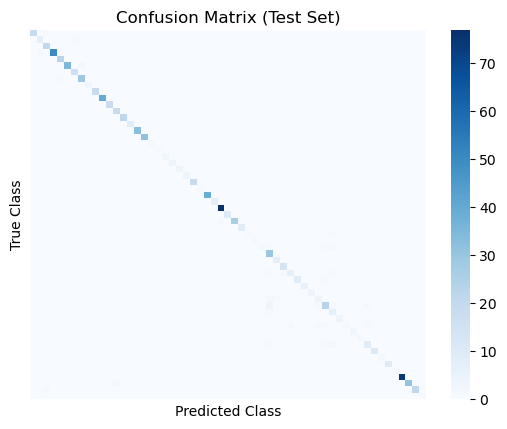

In [36]:
# Evaluate model performance on test set

evaluate_model_performance(model, X_test_proc, y_test_proc, LABELS, "Test")

Results from predictions on the test set are similar to those for predictions on the validation set; overall accuracy remains high (~96%); the confusion matrix is almost identical.

This model effectively predicts Chinese traffic sign type from an image file, with accuracy around 96%. Improvements to accuracy may be made by tweaking model structure and compilation.

### 4. Building, training, and evaluating a CNN with augmented training data

Data augmentation can improve CNN model performance, especially in areas of data scarcity. Data augmentation is the process of adding additional data to a training set by taking existing datapoints and altering them in some way to generate new datapoints. In this project, I randomly translate, rotate, zoom, and alter contrast of signs to provide new data, where each alteration doesn't alter the original sign label. This generates many new datapoints that can be used in the training set.

#### Building the model

`tensorflow.layers` is used to create this data augmentation layer within the CNN architecture. To determine solely the effect of augmentation on CNN performance for this data, the rest of the CNN architecture is the same as that of the original CNN model.

In [12]:
from tensorflow.keras import layers

# Building with data augmentation

data_aug = Sequential([
    layers.RandomRotation(0.08), 
    layers.RandomZoom(0.1),     
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.2, 0.2)
])

model_aug = Sequential([layers.Input(shape=(img_size, img_size, 3)),

                        data_aug,   # data augmentation layer
    
                        Conv2D(32, (3, 3), activation='relu'),
                        MaxPooling2D((2, 2)),

                        Conv2D(64, (3, 3), activation='relu'),
                        MaxPooling2D((2, 2)),

                        Conv2D(128, (3, 3), activation='relu'),
                        MaxPooling2D((2, 2)),

                        Flatten(),

                        Dense(num_cat, activation='softmax')

                        ])

model_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 58)             │        29,754 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,002 (480.48 KB)

 Trainable params: 123,002 (480.48 KB)

 Non-trainable params: 0 (0.00 B)

#### Compiling and training the model

In [13]:
model_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_aug = model_aug.fit(
    X_train_proc,
    y_train_proc,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_proc, y_val_proc),
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", restore_best_weights=True)]
)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.1269 - loss: 3.4204 - val_accuracy: 0.2288 - val_loss: 2.9141
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2785 - loss: 2.6759 - val_accuracy: 0.3443 - val_loss: 2.2905
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3357 - loss: 2.2598 - val_accuracy: 0.3379 - val_loss: 2.1039
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3586 - loss: 2.1036 - val_accuracy: 0.4237 - val_loss: 1.8630
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4047 - loss: 1.9670 - val_accuracy: 0.4894 - val_loss: 1.6995
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4363 - loss: 1.8302 - val_accuracy: 0.5000 - val_loss: 1.5161
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4761 - loss: 1.7050 - val_accuracy: 0.5720 - val_loss: 1.3311
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5229 - loss: 1.5637 - val_accuracy: 0.5922 - v

Validation accuracy improves over epochs, just as occurred for the previous model, however accuracy is far lower. Loss function values are also higher than for the original model used. Further analysis of these findings is given below.

#### Detailed model evaluation on the validation set

A classification report and confusion matrix are created to display results for final model fitting on the validation data.

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
                                                            precision    recall  f1-score   support

                                      Speed limit (5 km/h)      0.864     0.950     0.905        20
                                     Speed limit (15 km/h)      0.000     0.000     0.000         8
                                     Speed limit (30 km/h)      0.500     0.048     0.087        21
                                     Speed limit (40 km/h)      0.468     0.679     0.554        53
                                     Speed limit (50 km/h)      0.625     0.208     0.312        24
                                     Speed limit (60 km/h)      0.333     0.622     0.434        37
                                     Speed limit (70 km/h)      1.000     0.235     0.381        17
                                     Speed limit (80 km/h)      0.643     0.581     0.610        31
                 No driving straight ahead or turning left  

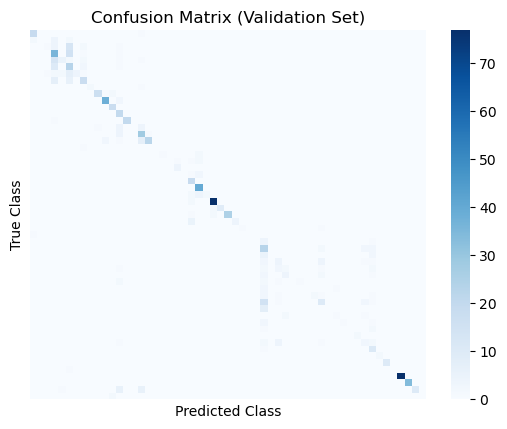

In [14]:
# Evaluate model performance on validation set

evaluate_model_performance(model_aug, X_val_proc, y_val_proc, LABELS, "Validation")

Precision, recall, and F1 scores are reasonably consistent across the board, yet some sign types appear to be confused more often than others. Overall accuracy takes a hit when compared to the original model (~68%). 

The confusion matrix backs this up, where certain sign classes are shown to be mixed up more frequently than others.

Test set evaluation (below) provides the best metrics for evaluation of this model's performance.

#### Detailed model evaluation on test set

A classification report and confusion matrix are created to display results for final model fitting on the test set data.

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
                                                            precision    recall  f1-score   support

                                      Speed limit (5 km/h)      0.950     0.950     0.950        20
                                     Speed limit (15 km/h)      1.000     0.375     0.545         8
                                     Speed limit (30 km/h)      1.000     0.095     0.174        21
                                     Speed limit (40 km/h)      0.492     0.577     0.531        52
                                     Speed limit (50 km/h)      0.750     0.130     0.222        23
                                     Speed limit (60 km/h)      0.333     0.730     0.458        37
                                     Speed limit (70 km/h)      0.714     0.312     0.435        16
                                     Speed limit (80 km/h)      0.704     0.633     0.667        30
                 No driving straight ahead or turning left  

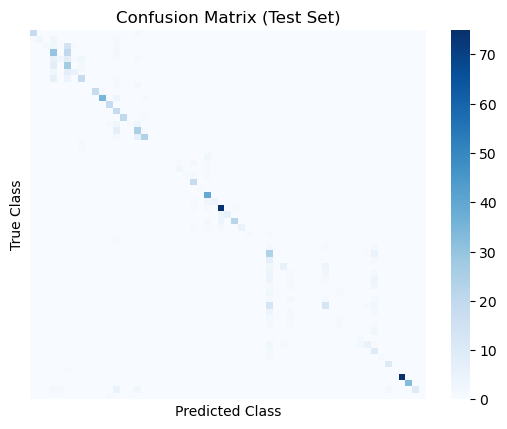

In [15]:
# Evaluate model performance on test set

evaluate_model_performance(model_aug, X_test_proc, y_test_proc, LABELS, "Test")

Results from test set predictions are very similar to those from the validation set, with certain sign classes being confused more than others. Overall accuracy is quite similar to predictions on the validation set (~68%). The confusion matrix is also quite similar to the one created using predictions from the validation set.

Since the original model (no augmentation) already achieved high accuracy, adding the augmentation likely creates noise that clouds the training signal and lowers overall accuracy of the model. Augmentation is helpful for reducing bias and increasing variance in training, which can be helpful in preventing overfitting. However, since accuracy is already quite high for training, validation, and testing sets for the model without augmentation (indicating minimal overfitting), this means that reduced bias/increased variance is not necessary for model improvement, and instead has the converse effect. 

### 5. Training and evaluating a publicly-available CNN on this dataset

MobileNetV2 is a publicly-available CNN created by Google that has been benchmarked thoroughly for image classification tasks. The model can be directly imported through TensorFlow. Here, I train the model and evaluate performance on the Chinese traffic sign dataset to compare to the basic CNN model I created.

#### Resize images for CNN input

MobileNetV2 (MNV2) requires 96x96 image format, while other models I previously used could take 32x32 images. All images must be resized for this model using TensorFlow's `image` module. 

Quick note: the images could be directly resized to 96x96 from their original sizes, which would likely give the highest accuracy for MNV2 models (more detailed and therefore distinct geometric patterns can be used to determine image class). However, to compare results effectively between MNV2 models and the others built and evaluated that use 32x32 images, the 32x32 images are simply resized to 96x96 to provide the same quality of images given to the first two models. This allows for effective comparisons between all models tested.

In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow import image

mnv2_img_size = 96   # minimum image width and height required for MNV2

X_train_resize = np.array(image.resize(X_train_proc, (mnv2_img_size, mnv2_img_size)))
X_val_resize = np.array(image.resize(X_val_proc, (mnv2_img_size, mnv2_img_size)))
X_test_resize = np.array(image.resize(X_test_proc, (mnv2_img_size, mnv2_img_size)))

#### Building the model

The model is already built, although a few things must be defined by a user for the base model and for the overall model architecture. `base_model.trainable` is set to `False` so that the base model's weights are not adjusted during training. For the overall model architecture, an additional pooling layer and dense layer are included to obtain the proper categorization outputs for this specific dataset. 

In [17]:
base_model = MobileNetV2(
    input_shape=(mnv2_img_size, mnv2_img_size, 3),
    include_top=False,      # use custom final classification layers specific for this project
    weights='imagenet'      # use MNV2's own weights and biases
)

base_model.trainable = False    # prevent training of base model parameters

model_mnv2 = Sequential([base_model,
                         
                         layers.GlobalAveragePooling2D(),   # similar to flattening, 
                                                            # but takes averages of 
                                                            # values to reduce total 
                                                            # parameters input into 
                                                            # dense layer

                         Dense(num_cat, activation='softmax')

                         ])

model_mnv2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 58)             │        74,298 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,332,282 (8.90 MB)

 Trainable params: 74,298 (290.23 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

This model contains many parameters (far more than the previous two I built), although many of them are non-trainable, as we want to keep the model's original weights and biases. 

#### Compiling and training the model

In [18]:
model_mnv2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_mnv2 = model_mnv2.fit(
    X_train_resize,
    y_train_proc,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_resize, y_val_proc),
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", restore_best_weights=True)]
)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.5551 - loss: 1.7879 - val_accuracy: 0.7945 - val_loss: 0.7909
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.8631 - loss: 0.5693 - val_accuracy: 0.8697 - val_loss: 0.4701
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9295 - loss: 0.3394 - val_accuracy: 0.9258 - val_loss: 0.3467
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.9644 - loss: 0.2288 - val_accuracy: 0.9534 - val_loss: 0.2615
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9788 - loss: 0.1686 - val_accuracy: 0.9534 - val_loss: 0.2242
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9846 - loss: 0.1308 - val_accuracy: 0.9587 - val_loss: 0.1927
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.9900 - loss: 0.1049 - val_accuracy: 0.9629 - val_loss: 0.1725
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.9935 - loss: 0.0871 - val_accuracy: 0.96

As with the other models, accuracy improves while the loss function values decrease over epochs. Training and validation accuracy are consistent and high (~97%), indicating minimal overfitting and accurate predictions made by the model.

#### Detailed model evaluation on the validation set

A classification report and confusion matrix are created to display results for final model fitting on the validation data.

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
                                                            precision    recall  f1-score   support

                                      Speed limit (5 km/h)      1.000     0.950     0.974        20
                                     Speed limit (15 km/h)      1.000     1.000     1.000         8
                                     Speed limit (30 km/h)      0.840     1.000     0.913        21
                                     Speed limit (40 km/h)      0.980     0.943     0.962        53
                                     Speed limit (50 km/h)      0.833     0.833     0.833        24
                                     Speed limit (60 km/h)      0.971     0.919     0.944        37
                                     Speed limit (70 km/h)      1.000     0.824     0.903        17
                                     Speed limit (80 km/h)      0.939     1.000     0.969        31
                 No driving straight ahead or turning left 

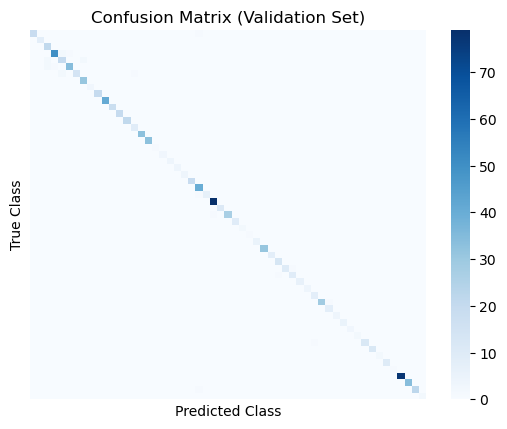

In [38]:
# Evaluate model performance on validation set

evaluate_model_performance(model_mnv2, X_val_resize, y_val_proc, LABELS, "Validation")

Results for predictions on the validation set are similar to those of the first model tested. Precision, recall, and F1 scores are consistent and high across the board, with high averages. Overall accuracy is high (~98%). The confusion matrix has a near-perfect diagonal indicative of highly accurate predictions by the model.

#### Detailed model evaluation on test set

A classification report and confusion matrix are created to display results for final model fitting on the test set data.

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step
                                                            precision    recall  f1-score   support

                                      Speed limit (5 km/h)      1.000     0.950     0.974        20
                                     Speed limit (15 km/h)      1.000     1.000     1.000         8
                                     Speed limit (30 km/h)      1.000     1.000     1.000        21
                                     Speed limit (40 km/h)      0.981     0.981     0.981        52
                                     Speed limit (50 km/h)      1.000     0.913     0.955        23
                                     Speed limit (60 km/h)      0.919     0.919     0.919        37
                                     Speed limit (70 km/h)      1.000     0.938     0.968        16
                                     Speed limit (80 km/h)      0.875     0.933     0.903        30
                 No driving straight ahead or turning left 

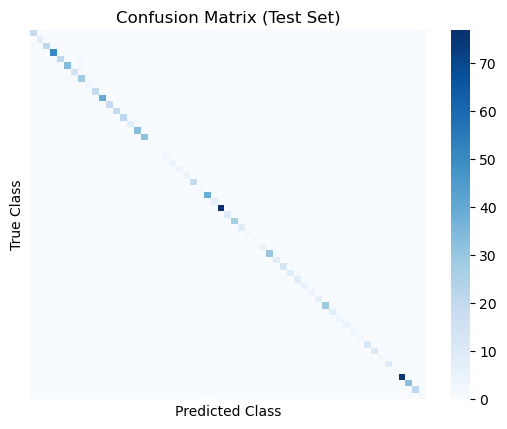

In [32]:
# Evaluate model performance on test set

evaluate_model_performance(model_mnv2, X_test_resize, y_test_proc, LABELS, "Test")

Results are almost identical to those from validation predictions. With the best overall accuracy for test set predictions of any model so far (~98%), this is the best candidate for the final model to choose for implementation in a user-friendly execution script.

### 6. Training and evaluating MNV2 with certain trainable layers

While the base MNV2 model achieved high prediction accuracy on this dataset, it's possible that performance could be improved by allowing certain layers of the base model to be trained specific for the dataset chosen.

Using the base model trained on other image data and tuning it for this specific dataset is a great example of transfer learning, which is commonly used to build high-performing machine learning models with less aggressive time, computing, and dataset scale restraints as are present when building a model from scratch. Transfer learning is especially useful in areas of data scarcity.

#### Building the model

In this case, I set only the final 10 layers of the base model as trainable. This was an arbitrary choice; more or less could be chosen, although the more layers that are trainable, the longer training takes, and this model already takes far longer than the original model I built myself.

The rest of the model architecture and base model settings are identical to those used in the previous MNV2 run, so that I am only comparing the model with and without some trainable layers for this dataset.

In [22]:
base_model = MobileNetV2(
    input_shape=(mnv2_img_size, mnv2_img_size, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = True     # allow some layers of base model to be retrained

for layer in base_model.layers[:-10]:       # specifically, allow final 10 layers to be retrained
    layer.trainable = False

model_mnv2_tp = Sequential([base_model,
                         
                         layers.GlobalAveragePooling2D(),

                         Dense(num_cat, activation='softmax')

                         ])

model_mnv2_tp.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 58)             │        74,298 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,332,282 (8.90 MB)

 Trainable params: 806,778 (3.08 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

Far more trainable parameters than for the base model with all non-trainable parameters, indicating this model was built properly.

#### Compiling and training the model

The only difference between compiling this model vs. the previous two is the lower learning rate, which is helpful in preventing already fine-tuned weights from the model from being altered substantially and very quickly during training.

In [23]:
from tensorflow.keras.optimizers import Adam

model_mnv2_tp.compile(
    optimizer=Adam(learning_rate=1e-5),     # smaller learning rate to reweight slowly
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_mnv2_finetune = model_mnv2_tp.fit(
    X_train_resize,
    y_train_proc,
    epochs=50,                     
    batch_size=64,
    validation_data=(X_val_resize, y_val_proc),
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', restore_best_weights=True
    )]
)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.0922 - loss: 3.8983 - val_accuracy: 0.0763 - val_loss: 4.0890
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.3276 - loss: 2.8820 - val_accuracy: 0.2278 - val_loss: 3.3755
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.4938 - loss: 2.2228 - val_accuracy: 0.3019 - val_loss: 2.8595
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.6130 - loss: 1.7914 - val_accuracy: 0.3686 - val_loss: 2.4719
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.6834 - loss: 1.4928 - val_accuracy: 0.4354 - val_loss: 2.1621
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.7288 - loss: 1.2692 - val_accuracy: 0.5169 - val_loss: 1.9102
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.7676 - loss: 1.1005 - val_accuracy: 0.5710 - val_loss: 1.6983
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.7960 - loss: 0.9665 - val_accuracy: 0

Accuracy increases and loss decreases as with the other models. Validation accuracy is similar to both the base MNV2 model and the first CNN, but this model uses all 50 epochs without early stopping, indicating it was still optimizing when training ended—likely a result of the much larger number of trainable parameters requiring more epochs to fine-tune. Since validation accuracy is no better than the base MNV2 model despite the extra training, there's likely little benefit to trainable parameters in the base model here (more analysis below).

More epochs may have pushed validation accuracy higher still, but training already takes considerably longer per epoch than the other models, so I capped all models at 50 epochs to keep training time from outweighing the project's value as a portfolio piece.

#### Detailed model evaluation on the validation set

A classification report and confusion matrix are created to display results for final model fitting on the validation data.

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
                                                            precision    recall  f1-score   support

                                      Speed limit (5 km/h)      0.864     0.950     0.905        20
                                     Speed limit (15 km/h)      1.000     0.875     0.933         8
                                     Speed limit (30 km/h)      0.913     1.000     0.955        21
                                     Speed limit (40 km/h)      0.981     0.962     0.971        53
                                     Speed limit (50 km/h)      0.917     0.917     0.917        24
                                     Speed limit (60 km/h)      1.000     0.919     0.958        37
                                     Speed limit (70 km/h)      1.000     0.824     0.903        17
                                     Speed limit (80 km/h)      0.939     1.000     0.969        31
                 No driving straight ahead or turning left 

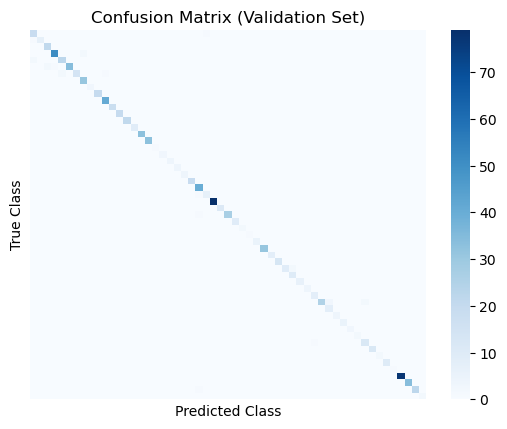

In [39]:
# Evaluate model performance on validation set

evaluate_model_performance(model_mnv2_tp, X_val_resize, y_val_proc, LABELS, "Validation")

Results are very similar to that of the previous MNV2 model, with consistent and high precision, recall, and F1 scores across the board, with high averages of each. Overall accuracy is similar as well (~98%). The confusion matrix yet again shows a near-perfect diagonal indicative of accurate image classification by the model.

#### Detailed model evaluation on test set

A classification report and confusion matrix are created to display results for final model fitting on the test set data.

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
                                                            precision    recall  f1-score   support

                                      Speed limit (5 km/h)      0.950     0.950     0.950        20
                                     Speed limit (15 km/h)      1.000     0.875     0.933         8
                                     Speed limit (30 km/h)      1.000     1.000     1.000        21
                                     Speed limit (40 km/h)      0.945     1.000     0.972        52
                                     Speed limit (50 km/h)      0.955     0.913     0.933        23
                                     Speed limit (60 km/h)      1.000     0.973     0.986        37
                                     Speed limit (70 km/h)      1.000     0.938     0.968        16
                                     Speed limit (80 km/h)      0.933     0.933     0.933        30
                 No driving straight ahead or turning left 

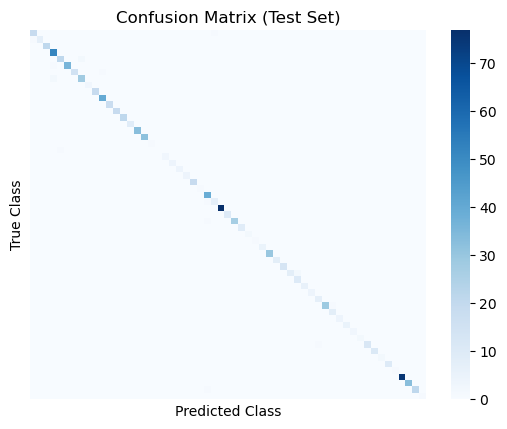

In [40]:
# Evaluate model performance on test set

evaluate_model_performance(model_mnv2_tp, X_test_resize, y_test_proc, LABELS, "Test")

Metrics are similar to the validation set, with test accuracy slightly higher than the base MNV2 model's—so this fine-tuned model is the final candidate for the prediction script.

Trainable parameters in the base model might be expected to outperform the frozen version, since fine-tuning can adapt weights to this specific dataset. But with a dataset this small, there's likely not enough data to fully shift the base model's pretrained spatial-pattern weights to a new optimum—they get knocked off their original values without fully converging on new ones, which can offset the benefit of fine-tuning. This lines up with the model still optimizing after all 50 epochs, suggesting a model this size and depth needs more data or time to fully adapt its weights.

A different number of trainable base layers could also be tested, though that's outside this project's scope. In practice, both MNV2 variants perform almost identically across multiple runs, with no strong preference between them—consistent with the idea that the epochs, learning rate, and number of trainable layers used here roughly balance the fine-tuning's benefit against its cost, landing this final model at a performance similar to the frozen base model.

### 7. Comparison of model results from test set predictions

A DataFrame is shown below that displays test set prediction accuracy and loss among all models used in this project for easy comparisons.

In [37]:
results = {}

# Original model
loss, acc = model.evaluate(X_test_proc, y_test_proc, verbose=0)
results['Original'] = {'Loss': loss, 'Accuracy': acc}

# Augmented model
loss, acc = model_aug.evaluate(X_test_proc, y_test_proc, verbose=0)
results['Augmented'] = {'Loss': loss, 'Accuracy': acc}

# MNV2
loss, acc = model_mnv2.evaluate(X_test_resize, y_test_proc, verbose=0)
results['MNV2'] = {'Loss': loss, 'Accuracy': acc}

# MNV2 with trainable parameters (final 10 layers)
loss, acc = model_mnv2_tp.evaluate(X_test_resize, y_test_proc, verbose=0)
results['MNV2 With Trainable Params'] = {'Loss': loss, 'Accuracy': acc}

final_results_df = pd.DataFrame(results).T

final_results_df['Loss'] = final_results_df['Loss'].apply('{:.3f}'.format)
final_results_df['Accuracy'] = final_results_df['Accuracy'].apply('{:.1%}'.format)

final_results_df

,Loss,Accuracy
Original,0.168,95.9%
Augmented,1.009,68.3%
MNV2,0.088,98.2%
MNV2 With Trainable Params,0.127,98.3%


As previously stated, the MNV2 models give similar overall accuracy of test set predictions. The final chosen model between these two is almost arbitrary and can vary by run, but, based on the current results, the final MNV2 model will be used in subsequent steps.

### Saving the model

The chosen model is then saved to disk for implementation in a Python script with a Bash wrapper for quick, interpretable, and human-readable classification of user-provided Chinese traffic sign images.

In [27]:
model_mnv2_tp.save('Chinese_Traffic_Sign_CNN_MNV2_tp.keras')